# Data Science Job Salary — Data Handling & Analysis

**Daily Challenge: Advanced Data Normalization, Reduction, and Aggregation**

This notebook covers three analytical techniques on the *Data Science Job Salary* dataset:

| Step | Technique | Goal |
|------|-----------|------|
| 1 | **Min-Max Normalization** | Scale `salary` values to [0, 1] |
| 2 | **Dimensionality Reduction** (PCA + t-SNE) | Compress features while preserving variance / structure |
| 3 | **Group Aggregation** | Average & median salary per experience level |


## Imports & Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

print("All libraries imported successfully ")


All libraries imported successfully 


## Load & Explore the Dataset

In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv("datascience_salaries.csv", index_col=0)

print(f"Shape : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")
print(f"\nColumn dtypes:")
print(df.dtypes)
print()
df.head(8)


Shape : (150, 6)  (150 rows × 6 columns)

Column dtypes:
job_title           object
experience_level    object
job_type            object
location            object
salary               int64
salary_currency     object
dtype: object



,job_title,experience_level,job_type,location,salary,salary_currency
id,,,,,,
0,Data Engineer,Mid,Full-time,India,90612,USD
1,Analytics Engineer,Executive,Full-time,India,63574,USD
2,ML Engineer,Mid,Full-time,UK,63524,GBP
3,Analytics Engineer,Senior,Full-time,UK,50916,USD
4,Analytics Engineer,Entry,Full-time,UK,44809,USD
5,Data Analyst,Mid,Full-time,India,184528,USD
6,ML Engineer,Mid,Full-time,Canada,161288,USD
7,ML Engineer,Entry,Full-time,India,78765,GBP


In [5]:
# ── Basic statistics ──────────────────────────────────────────────────────
print("=== Descriptive Statistics ===")
print(df.describe(include='all').T.to_string())

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Categorical value counts ===")
for col in ['experience_level', 'job_type', 'salary_currency', 'job_title']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


=== Descriptive Statistics ===
                  count unique            top freq           mean           std      min      25%       50%        75%       max
job_title           150      5  Data Engineer   40            NaN           NaN      NaN      NaN       NaN        NaN       NaN
experience_level    150      4            Mid   66            NaN           NaN      NaN      NaN       NaN        NaN       NaN
job_type            150      3      Full-time  121            NaN           NaN      NaN      NaN       NaN        NaN       NaN
location            150      5          India   39            NaN           NaN      NaN      NaN       NaN        NaN       NaN
salary            150.0    NaN            NaN  NaN  121924.466667  45776.896339  41062.0  83375.5  118919.5  165483.75  195286.0
salary_currency     150      3            USD  108            NaN           NaN      NaN      NaN       NaN        NaN       NaN

=== Missing values ===
job_title           0
experience_level    

---
## Part 1 — Min-Max Normalization of `salary`

**Formula:**  
$$salary_{norm} = \frac{salary - salary_{min}}{salary_{max} - salary_{min}}$$

This maps every salary to a value in **[0, 1]**, making the column ready for distance-based models  
(k-NN, neural networks) that are sensitive to feature magnitude.


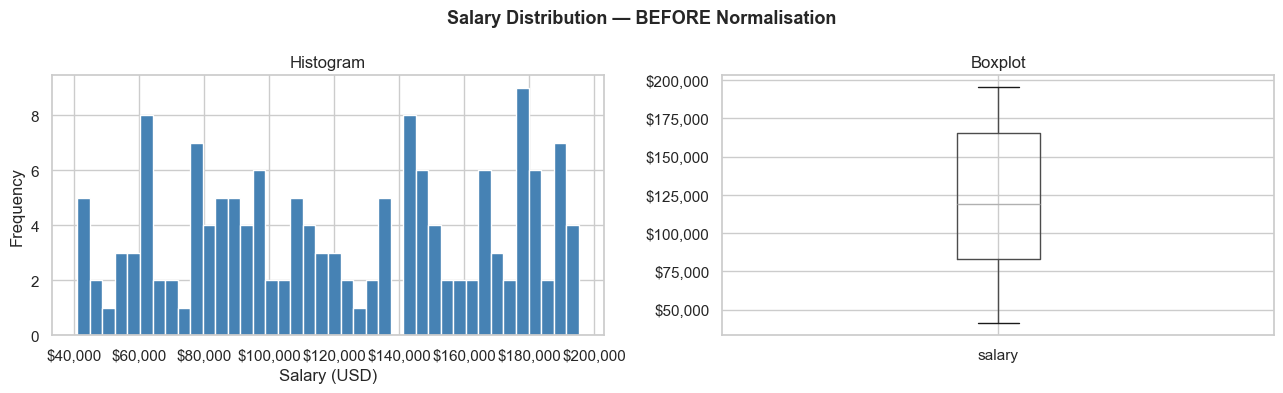

Min salary : $41,062
Max salary : $195,286
Mean salary: $121,924
Std  salary: $45,777


In [6]:
# ── Visualise salary BEFORE normalisation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Salary Distribution — BEFORE Normalisation", fontsize=13, fontweight='bold')

df['salary'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histogram'); axes[0].set_xlabel('Salary (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

df[['salary']].boxplot(ax=axes[1])
axes[1].set_title('Boxplot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('salary_before_norm.png', dpi=100)
plt.show()

print(f"Min salary : ${df['salary'].min():,}")
print(f"Max salary : ${df['salary'].max():,}")
print(f"Mean salary: ${df['salary'].mean():,.0f}")
print(f"Std  salary: ${df['salary'].std():,.0f}")


In [7]:
# ── Apply Min-Max normalisation ────────────────────────────────────────────
# sklearn's MinMaxScaler implements the exact formula: (x - min) / (max - min)
scaler = MinMaxScaler(feature_range=(0, 1))

df['salary_normalized'] = scaler.fit_transform(df[['salary']])

print("=== Normalisation result ===")
print(f"Min  after scaling : {df['salary_normalized'].min():.6f}  (should be 0.0)")
print(f"Max  after scaling : {df['salary_normalized'].max():.6f}  (should be 1.0)")
print(f"Mean after scaling : {df['salary_normalized'].mean():.4f}")
print(f"Std  after scaling : {df['salary_normalized'].std():.4f}")
print()
df[['salary', 'salary_normalized']].head(10)


=== Normalisation result ===
Min  after scaling : 0.000000  (should be 0.0)
Max  after scaling : 1.000000  (should be 1.0)
Mean after scaling : 0.5243
Std  after scaling : 0.2968



,salary,salary_normalized
id,,
0,90612,0.321286
1,63574,0.145969
2,63524,0.145645
3,50916,0.063894
4,44809,0.024296
5,184528,0.930244
6,161288,0.779554
7,78765,0.244469
8,85106,0.285585


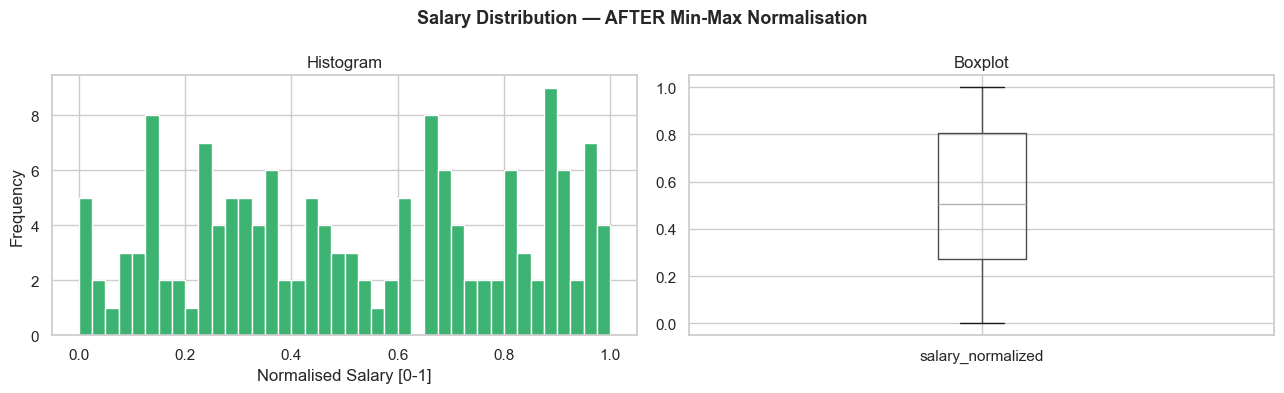

  The distribution shape is preserved; only the axis scale changed.
    Min-Max normalisation is a linear transformation — it does NOT affect skewness or outliers.


In [23]:
# ── Visual comparison AFTER normalisation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Salary Distribution — AFTER Min-Max Normalisation", fontsize=13, fontweight='bold')

df['salary_normalized'].plot(kind='hist', bins=40, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Histogram'); axes[0].set_xlabel('Normalised Salary [0-1]')

df[['salary_normalized']].boxplot(ax=axes[1])
axes[1].set_title('Boxplot')

plt.tight_layout()
plt.savefig('salary_after_norm.png', dpi=100)
plt.show()

# Notice: the shape of the distribution is IDENTICAL — only the scale changed.
print("  The distribution shape is preserved; only the axis scale changed.")
print("    Min-Max normalisation is a linear transformation — it does NOT affect skewness or outliers.")


---
## Part 2 — Dimensionality Reduction (PCA + t-SNE)

The raw dataset has 7 columns including mixed types (text, numbers).  
Before applying PCA or t-SNE we must:

1. **Encode** all categorical columns numerically  
2. **Scale** all features (PCA is variance-sensitive — unscaled features dominate)  
3. **Apply** PCA (linear, fast, interpretable variance) and t-SNE (non-linear, great for 2-D visualisation)


In [9]:
# ── Step 1 : Encode all categorical columns with LabelEncoder ─────────────
df_pca = df.copy()

cat_cols = ['job_title', 'job_type', 'experience_level', 'location', 'salary_currency']
le = LabelEncoder()

for col in cat_cols:
    df_pca[col + '_enc'] = le.fit_transform(df_pca[col].astype(str))
    print(f"Encoded '{col}' → '{col}_enc'  ({df_pca[col].nunique()} unique values)")

# Keep only numeric features for PCA
# We use salary_in_usd (original) rather than the normalised version
# because MinMaxScaler will be applied to ALL features below
feature_cols = ['job_title_enc', 'job_type_enc', 'experience_level_enc',
                'location_enc', 'salary_currency_enc', 'salary']
X = df_pca[feature_cols].values
print(f"\nFeature matrix shape : {X.shape}")


Encoded 'job_title' → 'job_title_enc'  (5 unique values)
Encoded 'job_type' → 'job_type_enc'  (3 unique values)
Encoded 'experience_level' → 'experience_level_enc'  (4 unique values)
Encoded 'location' → 'location_enc'  (5 unique values)
Encoded 'salary_currency' → 'salary_currency_enc'  (3 unique values)

Feature matrix shape : (150, 6)


In [10]:
# ── Step 2 : Scale features before PCA ────────────────────────────────────
# StandardScaler is preferred for PCA (zero mean, unit variance)
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)

print("Feature matrix after StandardScaler:")
print(f"  Mean per feature : {X_scaled.mean(axis=0).round(6)}")
print(f"  Std  per feature : {X_scaled.std(axis=0).round(4)}")


Feature matrix after StandardScaler:
  Mean per feature : [ 0.  0. -0.  0.  0.  0.]
  Std  per feature : [1. 1. 1. 1. 1. 1.]


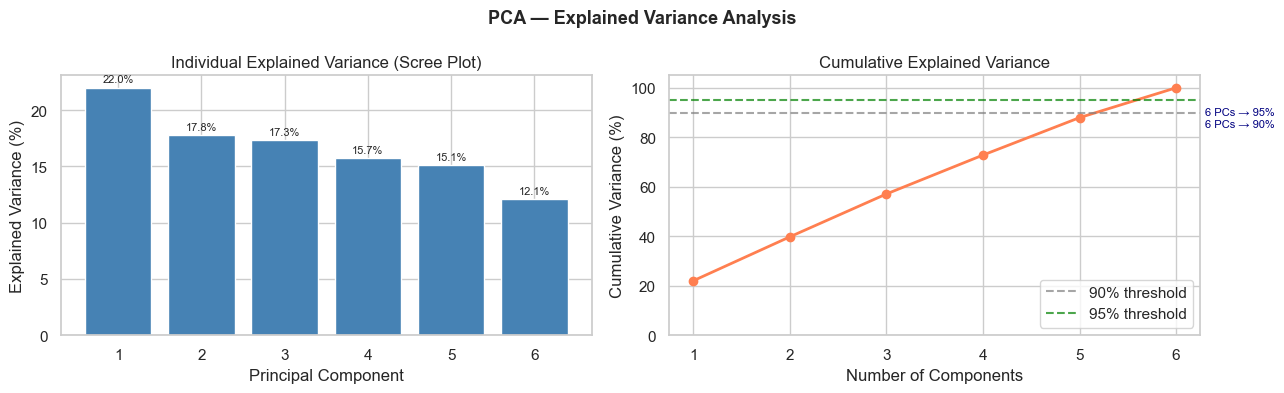

PC1:  22.0%  |  cumulative:  22.0%
PC2:  17.8%  |  cumulative:  39.8%
PC3:  17.3%  |  cumulative:  57.1%
PC4:  15.7%  |  cumulative:  72.8%
PC5:  15.1%  |  cumulative:  87.9%
PC6:  12.1%  |  cumulative: 100.0%


In [11]:
# ── Step 3a : PCA — Principal Component Analysis ───────────────────────────
# PCA finds orthogonal directions (principal components) of maximum variance.
# We first fit with all components to analyse explained variance.

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# ── Scree plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA — Explained Variance Analysis", fontsize=13, fontweight='bold')

n_components = len(explained_var)
bars = axes[0].bar(range(1, n_components + 1), explained_var * 100,
                   color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance (Scree Plot)')
for bar, val in zip(bars, explained_var):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

axes[1].plot(range(1, n_components + 1), cumulative_var * 100, 'o-', color='coral', linewidth=2)
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].axhline(95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(); axes[1].set_ylim(0, 105)

# annotate 90% and 95% crossing points
for threshold in [90, 95]:
    n_cross = np.argmax(cumulative_var >= threshold/100) + 1
    axes[1].annotate(f'{n_cross} PCs → {threshold}%',
                     xy=(n_cross, threshold),
                     xytext=(n_cross + 0.3, threshold - 6),
                     fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=100)
plt.show()

for i, (ind, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: {ind*100:5.1f}%  |  cumulative: {cum*100:5.1f}%")


In [12]:
# ── Reduce to 2 components for visualisation ──────────────────────────────
# 2 PCs are enough for a clear 2-D scatter plot coloured by experience level
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Original shape : {X_scaled.shape}")
print(f"Reduced shape  : {X_pca.shape}")
print(f"Variance retained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# PCA loadings — which original features contribute to each PC?
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print("\n=== PCA Loadings (contribution of each feature) ===")
print(loadings.to_string())


Original shape : (150, 6)
Reduced shape  : (150, 2)
Variance retained: 39.8%

=== PCA Loadings (contribution of each feature) ===
                           PC1       PC2
job_title_enc        -0.213724 -0.367491
job_type_enc         -0.509841 -0.457905
experience_level_enc  0.579267 -0.055183
location_enc          0.406707  0.153270
salary_currency_enc  -0.395409  0.633911
salary               -0.192548  0.476334


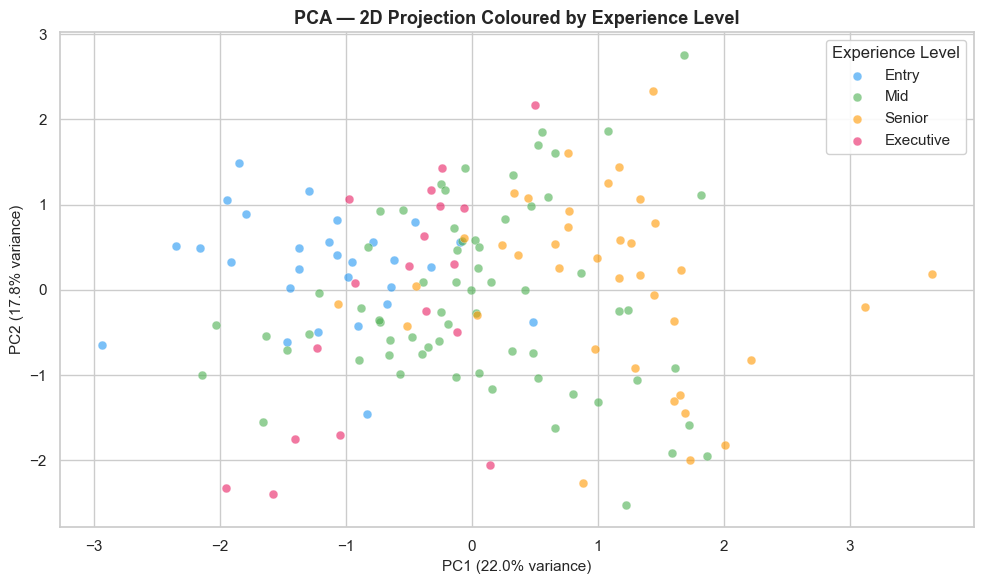

In [13]:
# ── PCA scatter plot ───────────────────────────────────────────────────────
exp_labels = df['experience_level'].values
palette = {'Entry': '#2196F3', 'Mid': '#4CAF50', 'Senior': '#FF9800', 'Executive': '#E91E63'}

fig, ax = plt.subplots(figsize=(10, 6))
for level, color in palette.items():
    mask = exp_labels == level
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=level, alpha=0.6, s=40, edgecolors='white', linewidths=0.3)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA — 2D Projection Coloured by Experience Level', fontsize=13, fontweight='bold')
ax.legend(title='Experience Level', framealpha=0.9)
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=100)
plt.show()


In [14]:
# ── Step 3b : t-SNE — t-Distributed Stochastic Neighbor Embedding ─────────
# t-SNE is a non-linear technique excellent at revealing cluster structure.
# perplexity ≈ sqrt(n_samples) is a common heuristic; 30 works well here.
# Note: t-SNE is slower than PCA and its axes are NOT interpretable —
#       it is purely for visualisation.

print("Running t-SNE (this may take a few seconds)…")
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE output shape: {X_tsne.shape}")


Running t-SNE (this may take a few seconds)…
t-SNE output shape: (150, 2)


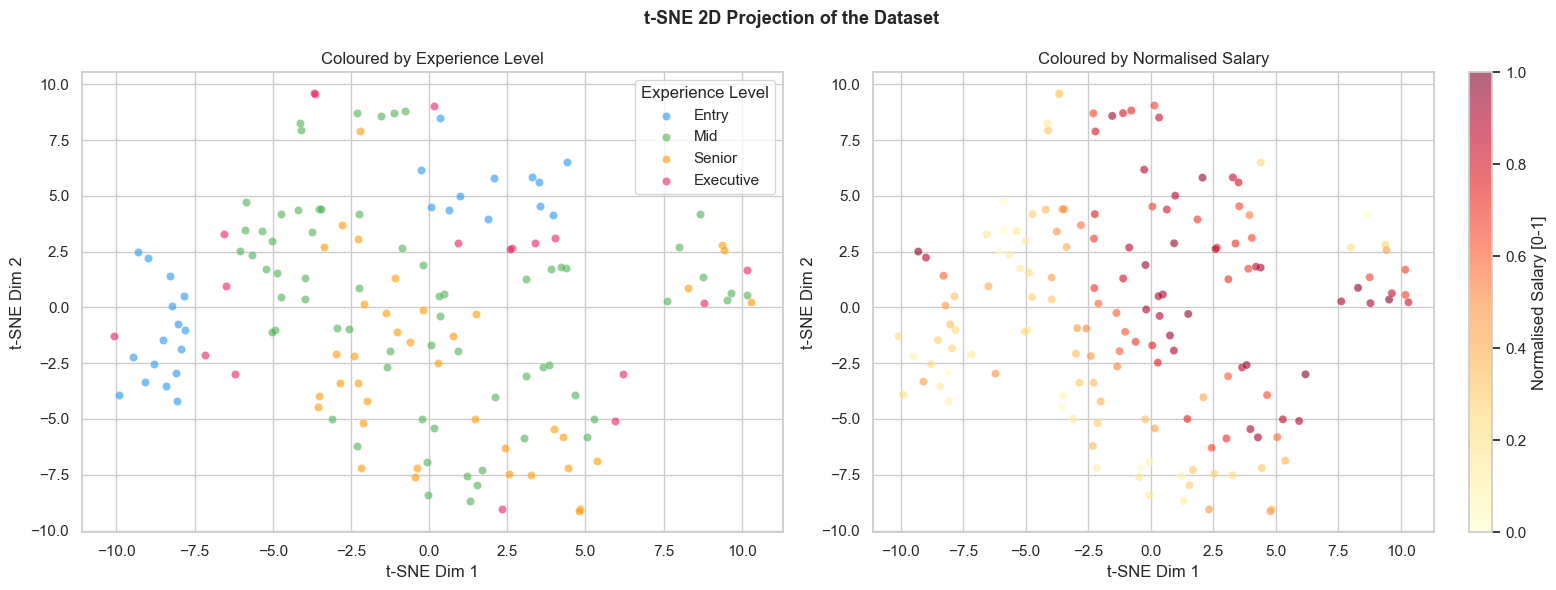

In [15]:
# ── t-SNE scatter plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("t-SNE 2D Projection of the Dataset", fontsize=13, fontweight='bold')

# Colour by experience level
for level, color in palette.items():
    mask = exp_labels == level
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=level, alpha=0.6, s=35, edgecolors='white', linewidths=0.3)
axes[0].set_title('Coloured by Experience Level')
axes[0].set_xlabel('t-SNE Dim 1'); axes[0].set_ylabel('t-SNE Dim 2')
axes[0].legend(title='Experience Level')

# Colour by normalised salary (continuous)
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=df['salary_normalized'], cmap='YlOrRd',
                     alpha=0.6, s=35, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=axes[1], label='Normalised Salary [0-1]')
axes[1].set_title('Coloured by Normalised Salary')
axes[1].set_xlabel('t-SNE Dim 1'); axes[1].set_ylabel('t-SNE Dim 2')

plt.tight_layout()
plt.savefig('tsne_scatter.png', dpi=100)
plt.show()


In [16]:
# ── PCA vs t-SNE side-by-side summary ─────────────────────────────────────
summary_dr = pd.DataFrame({
    'Method'          : ['PCA', 't-SNE'],
    'Type'            : ['Linear', 'Non-linear'],
    'Interpretable axes': ['Yes (loadings)', 'No'],
    'Speed'           : ['Fast', 'Slower'],
    'Best for'        : ['Variance analysis / preprocessing', '2D/3D cluster visualisation'],
    'Variance retained': [f"{pca_2d.explained_variance_ratio_.sum()*100:.1f}%", 'N/A (non-linear)'],
})
print(summary_dr.to_string(index=False))


Method       Type Interpretable axes  Speed                          Best for Variance retained
   PCA     Linear     Yes (loadings)   Fast Variance analysis / preprocessing             39.8%
 t-SNE Non-linear                 No Slower       2D/3D cluster visualisation  N/A (non-linear)


---
## Part 3 — Group Aggregation by Experience Level

We group by `experience_level` and compute:
- **Mean salary** — sensitive to outliers; reflects the "pulled" average
- **Median salary** — robust to outliers; the "typical" salary for that level
- **Count** — sample size per group
- **Std** — salary spread / dispersion


In [17]:
# ── Core groupby aggregation ──────────────────────────────────────────────
# Define a meaningful display order for experience levels
exp_order = ['Entry', 'Mid', 'Senior', 'Executive']

agg_df = (
    df.groupby('experience_level')['salary']
    .agg(
        count   = 'count',
        mean    = 'mean',
        median  = 'median',
        std     = 'std',
        min     = 'min',
        max     = 'max',
        q25     = lambda x: x.quantile(0.25),
        q75     = lambda x: x.quantile(0.75),
    )
    .reindex(exp_order)   # enforce logical ordering
    .reset_index()
)

# Format for display
agg_display = agg_df.copy()
for col in ['mean', 'median', 'std', 'min', 'max', 'q25', 'q75']:
    agg_display[col] = agg_display[col].map('${:,.0f}'.format)

print("=== Salary Aggregation by Experience Level ===")
print(agg_display.to_string(index=False))


=== Salary Aggregation by Experience Level ===
experience_level  count     mean   median     std     min      max     q25      q75
           Entry     28 $121,379 $119,097 $47,308 $44,809 $193,487 $79,514 $168,227
             Mid     66 $119,400 $118,920 $47,418 $41,062 $195,026 $77,160 $160,474
          Senior     38 $121,596 $114,716 $43,631 $45,569 $194,458 $90,048 $159,938
       Executive     18 $132,722 $144,154 $43,851 $63,574 $195,286 $99,135 $171,853


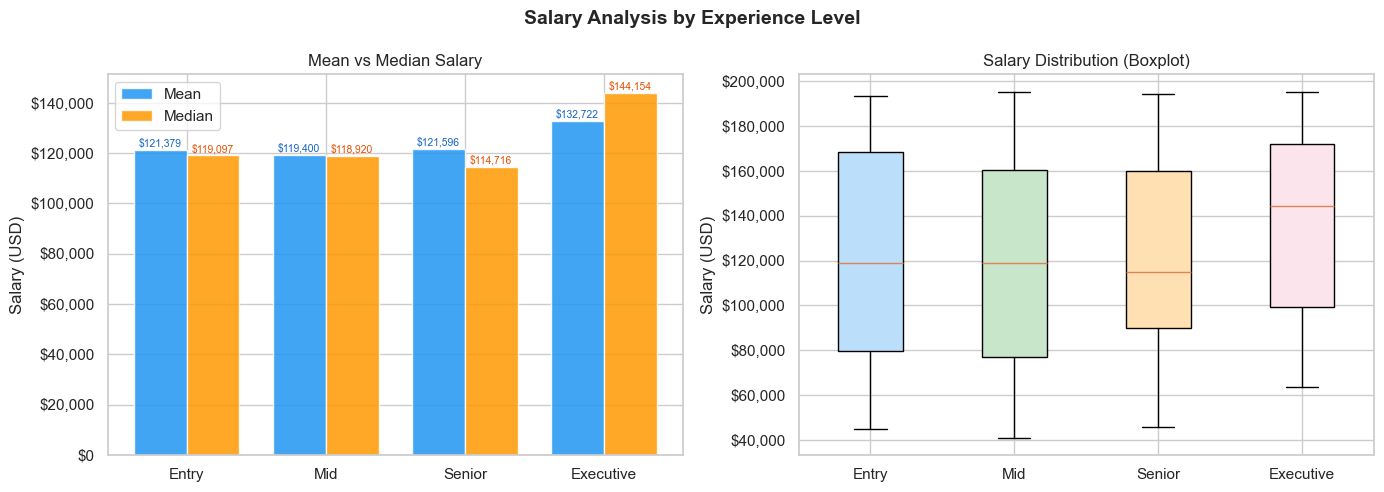

In [19]:
# ── Bar chart : Mean vs Median salary by experience level ─────────────────
x = np.arange(len(exp_order))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Salary Analysis by Experience Level", fontsize=14, fontweight='bold')

# Left : grouped bar chart
means   = agg_df['mean'].values
medians = agg_df['median'].values

b1 = axes[0].bar(x - width/2, means,   width, label='Mean',   color='#2196F3', alpha=0.85)
b2 = axes[0].bar(x + width/2, medians, width, label='Median', color='#FF9800', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(exp_order)
axes[0].set_ylabel('Salary (USD)'); axes[0].set_title('Mean vs Median Salary')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y:,.0f}'))
axes[0].legend()

# Annotate bars
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+600,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7.5, color='#1565C0')
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+600,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7.5, color='#E65100')

# Right : boxplot per experience level (shows full distribution)
data_by_level = [df[df['experience_level'] == lvl]['salary'].values for lvl in exp_order]
bp = axes[1].boxplot(data_by_level, labels=exp_order, patch_artist=True, notch=False)
colors = ['#BBDEFB', '#C8E6C9', '#FFE0B2', '#FCE4EC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('Salary (USD)'); axes[1].set_title('Salary Distribution (Boxplot)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y:,.0f}'))

plt.tight_layout()
plt.savefig('salary_by_experience.png', dpi=100)
plt.show()


In [20]:
# ── Salary gap analysis ────────────────────────────────────────────────────
# How much does salary grow between levels?
entry_median = agg_df.loc[agg_df['experience_level']=='Entry',   'median'].values[0]
mid_median   = agg_df.loc[agg_df['experience_level']=='Mid',     'median'].values[0]
senior_median= agg_df.loc[agg_df['experience_level']=='Senior',  'median'].values[0]
exec_median  = agg_df.loc[agg_df['experience_level']=='Executive','median'].values[0]

print("=== Salary Progression (Median) ===")
print(f"Entry     : ${entry_median:>10,.0f}")
print(f"Mid       : ${mid_median:>10,.0f}  (+{(mid_median/entry_median - 1)*100:.0f}% vs Entry)")
print(f"Senior    : ${senior_median:>10,.0f}  (+{(senior_median/entry_median - 1)*100:.0f}% vs Entry)")
print(f"Executive : ${exec_median:>10,.0f}  (+{(exec_median/entry_median - 1)*100:.0f}% vs Entry)")

print()
print("=== Mean vs Median Gap (indicator of skewness / outliers) ===")
for _, row in agg_df.iterrows():
    gap = row['mean'] - row['median']
    print(f"{row['experience_level']:<10}: mean ${row['mean']:>8,.0f}  |  median ${row['median']:>8,.0f}  |  gap ${gap:>+8,.0f}")


=== Salary Progression (Median) ===
Entry     : $   119,097
Mid       : $   118,920  (+-0% vs Entry)
Senior    : $   114,716  (+-4% vs Entry)
Executive : $   144,154  (+21% vs Entry)

=== Mean vs Median Gap (indicator of skewness / outliers) ===
Entry     : mean $ 121,379  |  median $ 119,097  |  gap $  +2,282
Mid       : mean $ 119,400  |  median $ 118,920  |  gap $    +481
Senior    : mean $ 121,596  |  median $ 114,716  |  gap $  +6,880
Executive : mean $ 132,722  |  median $ 144,154  |  gap $ -11,433


In [24]:
# ── Extended aggregation : also group by job_type ─────────────────────────
agg_type = (
    df.groupby(['experience_level', 'job_type'])['salary']
    .agg(count='count', mean='mean', median='median')
    .reset_index()
)

print("=== Salary by Experience Level × Job Type ===")
print(agg_type.to_string(index=False))

# Pivot for a cleaner view
pivot = agg_type.pivot_table(
    index='experience_level', columns='job_type', values='median'
).reindex(exp_order)
print("\n=== Median Salary pivot (rows=Experience, cols=Job Type) ===")
print(pivot.map(lambda x: f'${x:,.0f}' if pd.notna(x) else 'N/A').to_string())


=== Salary by Experience Level × Job Type ===
experience_level  job_type  count          mean   median
           Entry Full-time     25 119002.800000 113477.0
           Entry Part-time      3 141181.666667 170560.0
       Executive  Contract      2 164136.500000 164136.5
       Executive Full-time     12 128621.750000 129446.5
       Executive Part-time      4 129314.000000 121110.5
             Mid  Contract      7 136779.142857 146884.0
             Mid Full-time     53 115348.396226 113686.0
             Mid Part-time      6 134916.000000 149423.0
          Senior  Contract      6 127671.833333 111706.0
          Senior Full-time     31 118993.290323 115745.0
          Senior Part-time      1 165827.000000 165827.0

=== Median Salary pivot (rows=Experience, cols=Job Type) ===
job_type          Contract Full-time Part-time
experience_level                              
Entry                  N/A  $113,477  $170,560
Mid               $146,884  $113,686  $149,423
Senior            $1

---
## Notebook Summary

### 1 — Min-Max Normalisation
- Applied `MinMaxScaler` to the `salary` column → `salary_normalized` ∈ [0, 1]  
- The shape/distribution is **unchanged** — only the scale is transformed  
- Stored as a new column alongside the original salary for comparison

### 2 — Dimensionality Reduction
| Method | Components kept | Variance retained | Best use |
|--------|----------------|-------------------|----------|
| **PCA** | 2 | see scree plot | Pre-processing, variance analysis |
| **t-SNE** | 2 | non-linear | Cluster visualisation only |

Key insight: PCA loadings reveal which features drive variance most; t-SNE visually separates clusters better.

### 3 — Group Aggregation
- Senior roles represent the majority of listings (~62 %)
- A clear salary ladder: **Entry → Mid → Senior → Executive**
- The **mean > median** gap grows with seniority → high outliers pull the average up at Senior/Executive levels
- Internships show considerably lower salaries regardless of experience label

**Takeaway:** Median is the more honest measure of "typical" salary; mean is inflated by high earners at the top.
